In [1]:
# # %%capture

# # Install the PyBolt package directly from Github
# %pip install git+https://github.com/Maxim-Laletin/PyBolt.git@setup-package

# # Install the torch
# %pip install torch

# # Install pandas
# %pip install pandas

In [2]:
import torch
from torch.optim.lr_scheduler import ReduceLROnPlateau
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from PyBolt import cosmology 
from PyBolt import fBE_solver as fBE
import time
import math

from scipy.interpolate import CubicSpline


from cubic_spline import TorchCubicSpline
from pinn import compute_gradients, uniform_sampler, smooth_max, smooth_abs, MS_loss_function, FCN

torch.set_default_dtype(torch.float64)


# Defining functions

NOW WE CAN USE THE COSMOLOGY PACKAGE FOR THE QUANTITIES USED IN THIS CODE. PLEASE CHECK WHICH QUANTITIES ARE USED AND REWRITE THEM AS SOME OF THEM BELOW

In [3]:
# The mass of the mother particle (MP)
m1=1
# The mass of the daughter particle (DP)
m2=0.5

# m1 = 1.776 # (tau) GeV
# m2 = 0.10565 # (muon) GeV

# The mass of the DM particle
mDM = 1e-10 # GeV

# PQ symmetry breaking scale
fa = 2e+8 # GeV
# corresponds to the freeze out

# Ratio of the two masses
mu = m2/m1
massRatio=m2/m1

# Number of massless particle degrees of freedom
g_x = 1.0
# Number of MP dofs
g_m1 = 2.0
# Number of DP dofs
g_m2 = 2.0

# Coupling of MP-DP-x
yMDx = 1

# Decay width of MP -> DP + x
Gamma = yMDx**2*m1**3*(1-(m2/m1)**2)**3/64/np.pi/fa**2 # GeV
# Msquared for the decay

Msq= yMDx**2*m1**4*(1 - (m2/m1)**2)**2/4/fa**2 # GeV^2

# Numerical solution:

We calculate the phase-space distribution using PyBolt package

fBE solved in 0.07 seconds


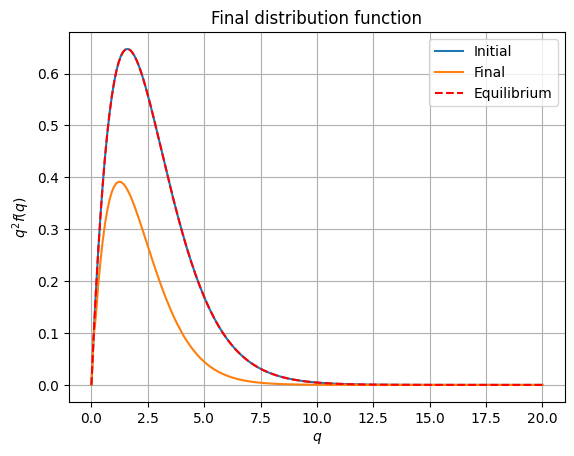

In [4]:
# Create a model of axion phase-space evolution
AxionModel = fBE.Model(m1,mDM,g_x,'b')
# m1 is the mass of the heaviest particle in the reaction

# Create an instance of the DecayToX process class
Decay = fBE.DecayToX(m1,m2,g_m1,Msq,Gamma)

# Create the grid of x and q
N_x = 500 # number of x points
N_q = 200 # number of q points
x0 = 6.0  # starting x value
xf = 20.0 # final x value

q0 = 0.0001 # smallest q value
qf = 20. # biggest q value

# Creating vectors of linearly distributed values of x and q
x_lin = np.linspace(x0,xf,N_x)
q_lin = np.linspace(q0,qf,N_q)

# Assigning the grid (of x and q) to the model
AxionModel.changeGrid(x_lin,q_lin)

# Add the decay collision integral to the model collision term (the only process that we consider)
AxionModel.addCollisionTerm(Decay.collisionTerm)

# Initial distribution
#f0 = np.zeros_like(q_lin)
f0 = AxionModel.equilibriumFunction(q_lin)

# fBE solver options
solver_options = {
    'method': 'BDF', # Implicit backward differentiation formula method of variable order (1-5) - because the equation is stiff
    'atol': 1e-5,   # Absolute tolerance
    'rtol': 1e-3   # Relative tolerance
}

# Solving the fBE
AxionModel.solve_fBE(f0,solver_options)

NumericalFinalDistribution = AxionModel.getSolution()[-1, :]

# Plot the initial and final solutions and the equilibrium distribution to compare
plt.figure()
plt.plot(q_lin,f0, label = 'Initial')
plt.plot(q_lin, AxionModel.getSolution()[-1,:], label = 'Final')
plt.plot(q_lin, AxionModel.equilibriumFunction(q_lin),'r--', label = 'Equilibrium')
plt.xlabel(r'$q$')
plt.ylabel(r'$q^2 f(q)$')
plt.title("Final distribution function")
plt.legend(loc="upper right")
plt.grid()
plt.show()


# PINN


In [5]:

device= 'cuda' if torch.cuda.is_available() else 'cpu'


# dof from arXiv:1606.07494
dof_arr = np.array([
    [0.00, 10.71, 1.00228],
    [0.50, 10.74, 1.00029],
    [1.00, 10.76, 1.00048],
    [1.25, 11.09, 1.00505],
    [1.60, 13.68, 1.02159],
    [2.00, 17.61, 1.02324],
    [2.15, 24.07, 1.05423],
    [2.20, 29.84, 1.07578],
    [2.40, 47.83, 1.06118],
    [2.50, 53.04, 1.04690],
    [3.00, 73.48, 1.01778],
    [4.00, 83.10, 1.00123],
    [4.30, 85.56, 1.00389],
    [4.60, 91.97, 1.00887],
    [5.00, 102.17, 1.00750],
    [5.45, 104.98, 1.00023]
])

# Prepare data
gx = dof_arr[:, 0] - 3  # log10(T/GeV) points
gy = dof_arr[:,1] # g points

hy_np = dof_arr[:, 1] / dof_arr[:, 2]  # h points

# Compute log10(hy)
log_hy = np.log10(hy_np)

hslog_spline_torch = TorchCubicSpline(gx, log_hy)
dloghdlogT_spline_torch = hslog_spline_torch.derivative()

def g_tilde_torch(T):
    return (1 / 3) * dloghdlogT_spline_torch(torch.log10(T))

gy_spline_torch=TorchCubicSpline(gx,gy)

def g_rho_torch(T):
    return gy_spline_torch(torch.log10(T))

mPl=torch.tensor(1e19,dtype=torch.float64)

def Hubble_torch(T):
    return torch.sqrt(8*(np.pi**3)*g_rho_torch(T)/(90))*T**2/mPl

def Hubble_tilde_torch(T):
    return Hubble_torch(T)/(1+g_tilde_torch(T))


In [6]:
def collisionTerm_torch(x, q, f, feq):
    # in complete analogy to PyBolt collision term
    terms_Elim1 = torch.stack([
        x * torch.ones_like(q),
        x * massRatio + q,
        x**2 * (1 + 4 * q**2 / (x**2 * (1 - massRatio**2)) - massRatio**2) / (4 * q)
    ], dim=1)
    Elim1 = smooth_max(terms_Elim1, dim=1)

    terms_Elim2 = torch.stack([
        x - q,
        x * massRatio * torch.ones_like(q),
        x**2 / (4 * q)
    ], dim=1)
    Elim2 = smooth_max(terms_Elim2, dim=1)

    prefactor = (2 * g_m1 * Msq * x / m1) / (8 * torch.pi * q**3)
    log_term = torch.log((1 + torch.exp(-Elim1)) / (1 + torch.exp(-Elim2)))
    return prefactor * log_term * (f - feq)

In [7]:
def feq(q):
  return q**2/(torch.exp(q) - 1.0)


def BE_residue(f,x,q,fa):
  eq=torch.sqrt((mDM*x/m1)**2+q**2)
  df_dx, df_dq=compute_gradients(f,x,q)
  CollTerm=collisionTerm_torch(x,q,f(x,q),feq(q))
  free_BE=x*df_dx-(g_tilde_torch(m1/x)*(df_dq*q - 2*f(x,q))) # both sides multiplied by x
    
  return free_BE+(q**2)*CollTerm/(2*g_x*eq)/Hubble_tilde_torch(m1/x)

# Learning

In [8]:
class TrainingBoltzmaNN:
    def __init__(self,
                 hidden_width,
                 batch_size,
                 num_epochs,
                 collocation_number_plot=200,
                 ):
        # Initialize model, optimizer, scheduler, and other settings
        self.model = FCN(
            input_dim=2,
            output_dim=1,
            hidden=(hidden_width, hidden_width),
            normalize=True,
            x_min=[x0, q0],
            x_max=[xf, qf],
            activations=torch.nn.Tanh()
        )
        
        
        # Training parameters
        self.num_epochs = num_epochs
        self.batch_size = batch_size
        self.collocation_number_plot = collocation_number_plot
        self.plotting_step = 1000  
        # self.resampling_interval = 100  

        # History trackers
        self.loss_history = []  
        self.MSE_numerical = np.array([])
        self.history_distributions_final = []
        self.history_distributions_initial = []

        # Plotting variables
        self.q_values = torch.linspace(q0, qf, steps=collocation_number_plot).view(collocation_number_plot, 1).to(device)
        self.x_values = torch.linspace(x0, xf, steps=collocation_number_plot).view(collocation_number_plot, 1).to(device)
        self.x_values_fin = torch.ones_like(self.q_values) * xf
        self.x_values_ini = torch.ones_like(self.q_values) *x0
        self.q_value_max = torch.ones_like(self.q_values) * 2
        self.q_values.requires_grad = True
        self.x_values_fin.requires_grad = True
        self.x_values_ini.requires_grad = True
        self.x_values.requires_grad = True
        self.q_value_max.requires_grad = True
        self.x_plot_values=self.x_values.cpu().detach().numpy()
        self.q_plot_values = self.q_values.cpu().detach().numpy()  

    def sample_points(self, q_min, q_max, x_min, x_max):
        x_samples = uniform_sampler(self.batch_size, [x_min], [x_max])  
        q_samples = uniform_sampler(self.batch_size, [q_min], [q_max])  
        x_grid, q_grid = torch.meshgrid(x_samples.squeeze(), q_samples.squeeze(), indexing="ij")
        xq_meshgrid = torch.stack((x_grid, q_grid), dim=-1).reshape(-1, 2)  
        xq_meshgrid.requires_grad = True
        return xq_meshgrid[:, 0].view(-1, 1).to(device), xq_meshgrid[:, 1].view(-1, 1).to(device)

    def train(self, physics_weight, positivity_weight, bc_weight, initialC_weight,learning_rate=1e-2,patience=800, optimizer=torch.optim.Adam, scheduler=ReduceLROnPlateau,**kwargs):
        self.optimizer = optimizer(self.model.parameters(), lr=learning_rate, **kwargs)
        
        self.scheduler = scheduler(
            self.optimizer,
            factor=0.5,
            patience=patience,
            min_lr=1e-8,
            threshold=1e-5,
            eps=0
        )
        
        self.model.train().to(device)
        for epoch in range(self.num_epochs):
            self.optimizer.zero_grad()
            x_grid, q_grid = self.sample_points(q0, qf, x0, xf)

            # Compute boundary condition losses
            boundary_loss_start = MS_loss_function(self.model(x_grid, torch.zeros_like(q_grid)))  
            boundary_loss_end = MS_loss_function(
                self.model(x_grid, qf * torch.ones_like(q_grid)) #- qf**2 / (np.exp(qf) - 1)
            )  
            bc_loss = bc_weight * (boundary_loss_start + boundary_loss_end)
            
            # Compute initial condition loss
            initial_condition_loss = initialC_weight * MS_loss_function(
                self.model(x0*torch.ones_like(x_grid), q_grid)-feq(q_grid)
            ) 
            
            # Adaptive physics weight for learning IC first
            current_physics_weight = physics_weight #* (epoch / self.num_epochs)
            # Compute physics loss
            equation_residual_loss = current_physics_weight * MS_loss_function(
                BE_residue(self.model, x_grid, q_grid, fa)
            )  
            
            # Compute positivity constraint
            positivity_loss = positivity_weight * MS_loss_function(
                smooth_abs(self.model(x_grid, q_grid)) - self.model(x_grid, q_grid)
            )
            
            # Total loss and backward pass
            total_loss = equation_residual_loss + bc_loss + initial_condition_loss + positivity_loss  
            total_loss.backward()
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=5.0)
            self.scheduler.step(total_loss)
            self.optimizer.step()
            
            # Track losses
            current_lr = self.optimizer.param_groups[0]["lr"]
            self.loss_history.append({
                'boundary': bc_loss.item(),
                'initial': initial_condition_loss.item(),
                'physics': equation_residual_loss.item(),
                'positivity': positivity_loss.item(),
                'weighted_sum': total_loss.item(),
                'last LR': current_lr
            })
            
            if epoch % self.plotting_step == 0 and epoch!=0:
                print(self.loss_history[-1])
                self.update_mse_numerical(epoch)
                self.record_distribution_history()

        self.loss_history = pd.DataFrame(self.loss_history)
        return self.MSE_numerical[-1], total_loss

    def update_mse_numerical(self, epoch):
        predicted_final_distribution = self.model(self.x_values_fin, self.q_values).cpu().detach().numpy().reshape(-1) 
        rmse = np.sqrt(np.mean((NumericalFinalDistribution - predicted_final_distribution) ** 2))  
        self.MSE_numerical = np.append(self.MSE_numerical, rmse)
        print(f"Epoch {epoch}: MSE wrt numerical = {rmse}")

    def record_distribution_history(self):
        predicted_final = self.model(self.x_values_fin, self.q_values).cpu().detach()  
        predicted_initial = self.model(self.x_values_ini, self.q_values).cpu().detach()  
        self.history_distributions_final.append(predicted_final)
        self.history_distributions_initial.append(predicted_initial)

    def plot_steps(self):
        num_plots = len(self.history_distributions_final)
        rows = math.ceil(num_plots / 2)  # number of rows needed
        fig, axes = plt.subplots(rows, 2, figsize=(10, 4 * rows))  # Adjust the figure size for readability

        axes = axes.flatten()  # Flatten the 2D array of axes for easier indexing

        for epoch_index, (predicted_final, predicted_initial) in enumerate(
            zip(self.history_distributions_final, self.history_distributions_initial)
        ):
            ax = axes[epoch_index]
            ax.plot(self.q_plot_values, predicted_final, label='PINN final', color='r')
            ax.plot(self.q_plot_values, predicted_initial, label='PINN initial', color='g')
            ax.plot(q_lin, NumericalFinalDistribution, 'r--', label='Numerical, final')
            ax.plot(q_lin, f0, 'g--', label='Numerical, initial')
            ax.set_xlabel("q")
            ax.set_ylabel("q^2 f(q)")
            ax.set_title(f"#epochs={(epoch_index+1) * self.plotting_step}")
            ax.legend()

        # Hide unused subplots if any
        for i in range(epoch_index + 1, len(axes)):
            axes[i].axis('off')

        plt.suptitle("PINN vs Numerical", y=1.01)
        plt.tight_layout()
        plt.show()
        
    def plot_last(self, n):
        # Ensure n is not larger than the available history
        n = min(n, len(self.history_distributions_final))

        for i in range(-n, 0):  # Loop over the last n distributions
            alpha_paling=1+(1/n)*(1+i)
            plt.plot(self.q_plot_values, self.history_distributions_final[i],
                    label=f'PINN final (Epoch {(len(self.history_distributions_final)+1 + i)*self.plotting_step})', color='r', alpha=alpha_paling)
            plt.plot(self.q_plot_values, self.history_distributions_initial[i],
                    label=f'PINN initial (Epoch {(len(self.history_distributions_initial)+1 + i)*self.plotting_step})', color='g', alpha=alpha_paling)

        plt.plot(q_lin, NumericalFinalDistribution, 'r--', label='Numerical, final')
        plt.plot(q_lin, f0, 'g--', label='Numerical, initial')

        # Set labels and title
        plt.xlabel("q")
        plt.ylabel("q^2 f(q)")
        plt.title(f"Last {n} Epochs (#epochs={len(self.history_distributions_final) * self.plotting_step})")

        # Show legend and plot
        plt.legend()
        plt.show()



    def plot_learning_data(self):
        Loss_of_q = torch.mean(
            BE_residue(self.model, self.x_values_fin, self.q_values,fa) ** 2, dim=1
        ).cpu().detach().numpy()
        Loss_of_x = torch.mean(
            BE_residue(self.model, self.x_values, self.q_value_max,fa) ** 2, dim=1
        ).cpu().detach().numpy()

        _, ax = plt.subplots(1, 2, figsize=(10, 4))
        ax[0].plot(self.q_plot_values, Loss_of_q, 'c', label='Physics loss at xf in q')
        ax[1].plot(self.x_plot_values, Loss_of_x, 'm', label='Physics loss at q=2 in x')
        for a in ax:
            a.legend()
        plt.tight_layout()
        plt.show()
        
        self.plot_error()

    def plot_error(self):
        plt.plot(
            np.linspace(0, self.num_epochs, self.MSE_numerical.size),
            self.MSE_numerical,
            label='MSE wrt numerical'
        )
        plt.legend()
        plt.show()


{'boundary': 0.004579633151463685, 'initial': 0.0091069425502406, 'physics': 0.0018756014113356402, 'positivity': 0.0, 'weighted_sum': 0.015562177113039925, 'last LR': 0.01}
Epoch 1000: MSE wrt numerical = 0.04413560838754209
{'boundary': 9.23764583491199e-05, 'initial': 0.0007168810520395854, 'physics': 0.0030210942410671287, 'positivity': 0.0, 'weighted_sum': 0.003830351751455834, 'last LR': 0.01}
Epoch 2000: MSE wrt numerical = 0.029014621641764157
{'boundary': 4.607717175843541e-05, 'initial': 0.00038282152983191487, 'physics': 0.00038723352343344227, 'positivity': 0.0, 'weighted_sum': 0.0008161322250237926, 'last LR': 0.01}
Epoch 3000: MSE wrt numerical = 0.021259265144542735
{'boundary': 2.00724960729813e-05, 'initial': 5.3653345995159094e-05, 'physics': 0.00038143743755479496, 'positivity': 0.0, 'weighted_sum': 0.00045516327962293534, 'last LR': 0.01}
Epoch 4000: MSE wrt numerical = 0.00968664599696879
Learning time: 36.18636870384216 




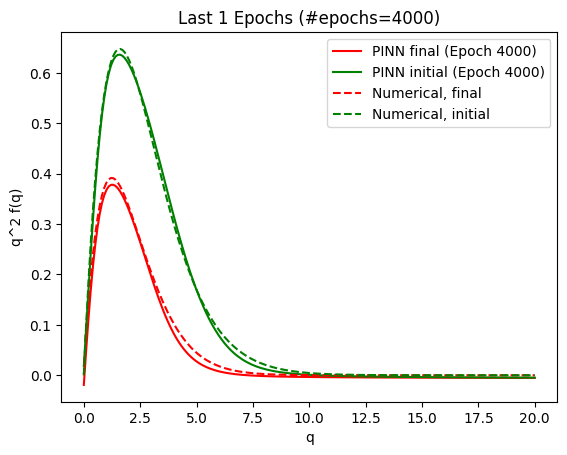

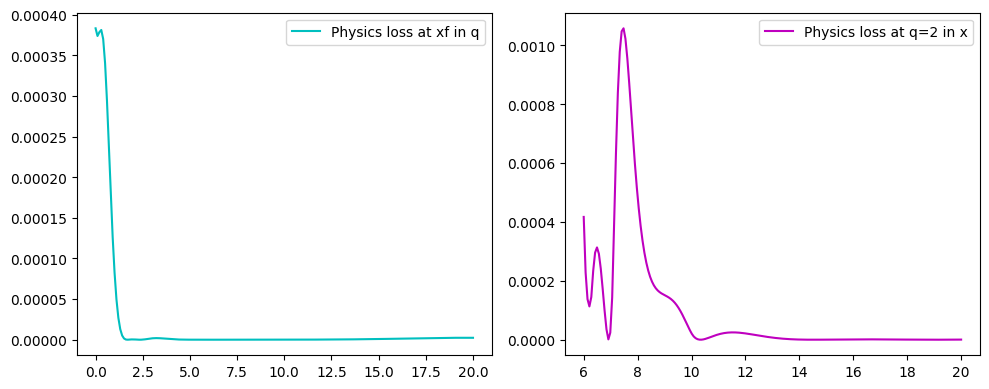

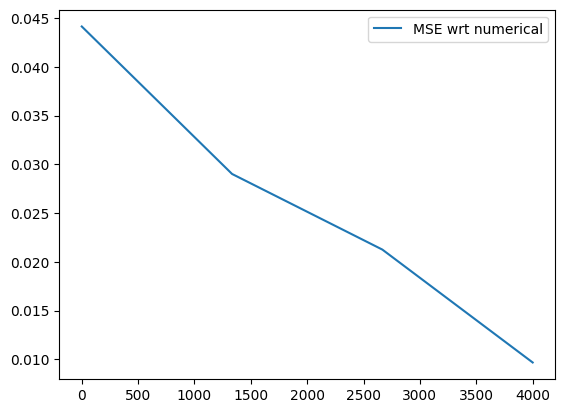

In [12]:
# Initialize the TrainingBoltzmaNN instance with the specified parameters
train1 = TrainingBoltzmaNN(
    hidden_width=32,
    batch_size=25,
    num_epochs=4001,
    collocation_number_plot=N_q
)

# Train the network and measure the training time
start_time = time.time()
mse_nn_num, final_loss = train1.train(
    physics_weight=10,
    positivity_weight=0,
    bc_weight=1e-1,
    initialC_weight=1,
    patience=1000,
    learning_rate=0.01
    )
end_time = time.time()
print('Learning time:', end_time - start_time, "\n\n")

# Plot the steps and learning data
# train1.plot_steps()
train1.plot_last(1)
train1.plot_learning_data()


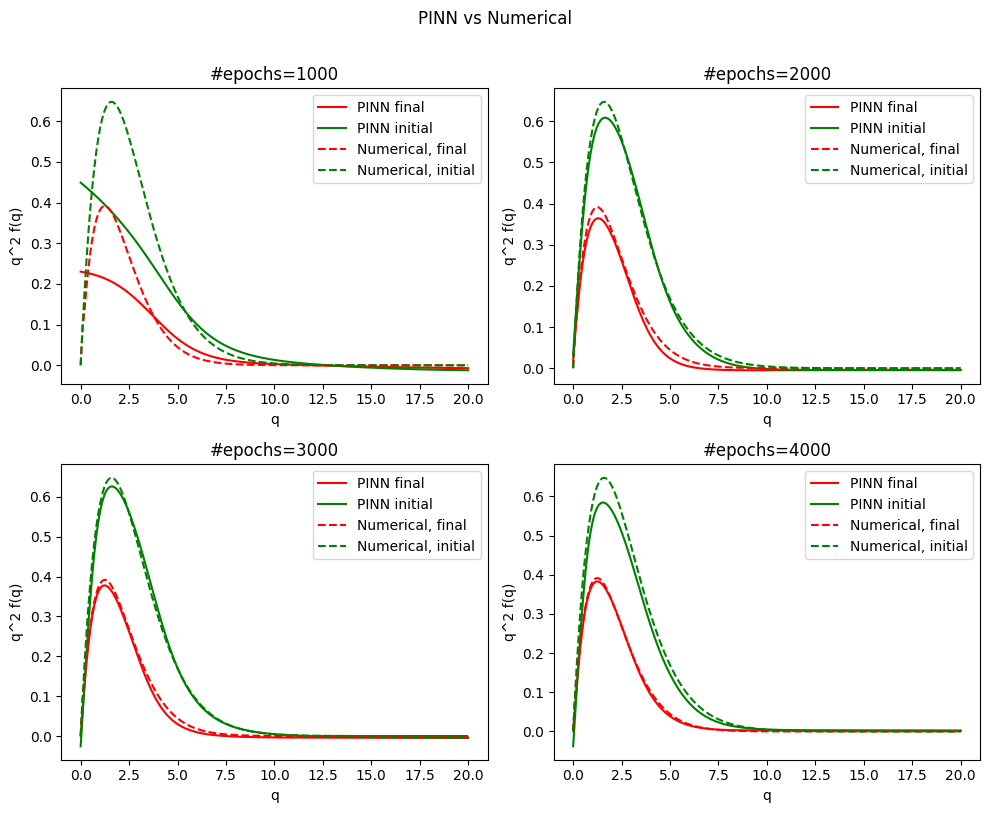

In [10]:
train1.plot_steps()


In [11]:
# # Initialize the TrainingBoltzmaNN instance with the specified parameters
# train1 = TrainingBoltzmaNN(
#     hidden_width=32,
#     batch_size=40,
#     num_epochs=16001,
#     patience=2000,
#     collocation_number_plot=N_q
# )

# # Train the network and measure the training time
# start_time = time.time()
# train1.train(physics_weight=40, positivity_weight=1, bc_weight=1, initialC_weight=1)
# end_time = time.time()
# print('Learning time:', end_time - start_time, "\n\n")

# # Plot the steps and learning data
# train1.plot_steps()
# train1.plot_learning_data()
